## Assignment 1:

- Using Numpy to implement the soft-margin SVM model. 
- Train this model using SGD method on the [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia). Resize the images to $128 \times 128$.
- Evaluate this model using Precision, Recall, and F1 metrics.

In [3]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ── 1. DATASET PATH ───────────────────────────────────────────────────────────
def find_split_dir(base: Path, split: str) -> Path:
    """Tìm đệ quy thư mục train/val/test dù dataset nằm ở tầng nào."""
    for p in base.rglob(split):
        if p.is_dir():
            children = [c.name for c in p.iterdir() if c.is_dir()]
            if any(c in children for c in ["NORMAL", "PNEUMONIA"]):
                return p
    raise FileNotFoundError(f"Cannot find '{split}' split under {base}")

DATA_ROOT = Path(r"C:\Users\DELL\Downloads\archive (1)")  


train_dir = find_split_dir(DATA_ROOT, "train")
val_dir   = find_split_dir(DATA_ROOT, "val")
test_dir  = find_split_dir(DATA_ROOT, "test")

print(f"✓ Dataset root : {DATA_ROOT.resolve()}")
print(f"  train → {train_dir}")
print(f"  val   → {val_dir}")
print(f"  test  → {test_dir}")

✓ Dataset root : C:\Users\DELL\Downloads\archive (1)
  train → C:\Users\DELL\Downloads\archive (1)\chest_xray\train
  val   → C:\Users\DELL\Downloads\archive (1)\chest_xray\val
  test  → C:\Users\DELL\Downloads\archive (1)\chest_xray\test


In [4]:
# ── 2. HYPER-PARAMETERS ───────────────────────────────────────────────────────
IMG_SIZE     = 128    # 128×128 grayscale
N_COMPONENTS = 150    # PCA dimensions
C            = 1.0    # SVM regularisation strength
LR           = 0.01   # initial learning rate
N_EPOCHS     = 50
BATCH_SIZE   = 64
LR_DECAY     = 0.95   # multiply lr by this each epoch

# ── 3. DATA LOADING ───────────────────────────────────────────────────────────
def load_split(split_dir: Path, img_size: int = 128):
    """
    Load images from  split_dir / {NORMAL, PNEUMONIA}.
    Returns
        X : float32 ndarray (N, img_size²)  values in [0, 1]
        y : int32   ndarray (N,)             NORMAL=-1, PNEUMONIA=+1
    """
    label_map = {"NORMAL": -1, "PNEUMONIA": 1}
    images, labels = [], []

    for cls, lbl in label_map.items():
        cls_dir = split_dir / cls
        if not cls_dir.exists():
            raise FileNotFoundError(cls_dir)
        files = sorted(cls_dir.glob("*.*"))
        for fpath in files:
            if fpath.suffix.lower() not in {".jpeg", ".jpg", ".png"}:
                continue
            try:
                img = (Image.open(fpath)
                            .convert("L")                       
                            .resize((img_size, img_size),
                                    Image.BILINEAR))
                images.append(np.array(img, dtype=np.float32).flatten() / 255.0)
                labels.append(lbl)
            except Exception as e:
                print(f"  skip {fpath.name}: {e}")

        print(f"  {split_dir.name}/{cls}: {sum(l == lbl for l in labels)} imgs")

    return np.stack(images), np.array(labels, dtype=np.int32)


print("\nLoading …")
t0 = time.time()
X_train, y_train = load_split(train_dir, IMG_SIZE)
X_val,   y_val   = load_split(val_dir,   IMG_SIZE)
X_test,  y_test  = load_split(test_dir,  IMG_SIZE)
print(f"Done in {time.time()-t0:.1f}s")
print(f"  Train {X_train.shape}  Val {X_val.shape}  Test {X_test.shape}")


Loading …
  train/NORMAL: 1341 imgs
  train/PNEUMONIA: 3875 imgs
  val/NORMAL: 8 imgs
  val/PNEUMONIA: 8 imgs
  test/NORMAL: 234 imgs
  test/PNEUMONIA: 390 imgs
Done in 201.2s
  Train (5216, 16384)  Val (16, 16384)  Test (624, 16384)


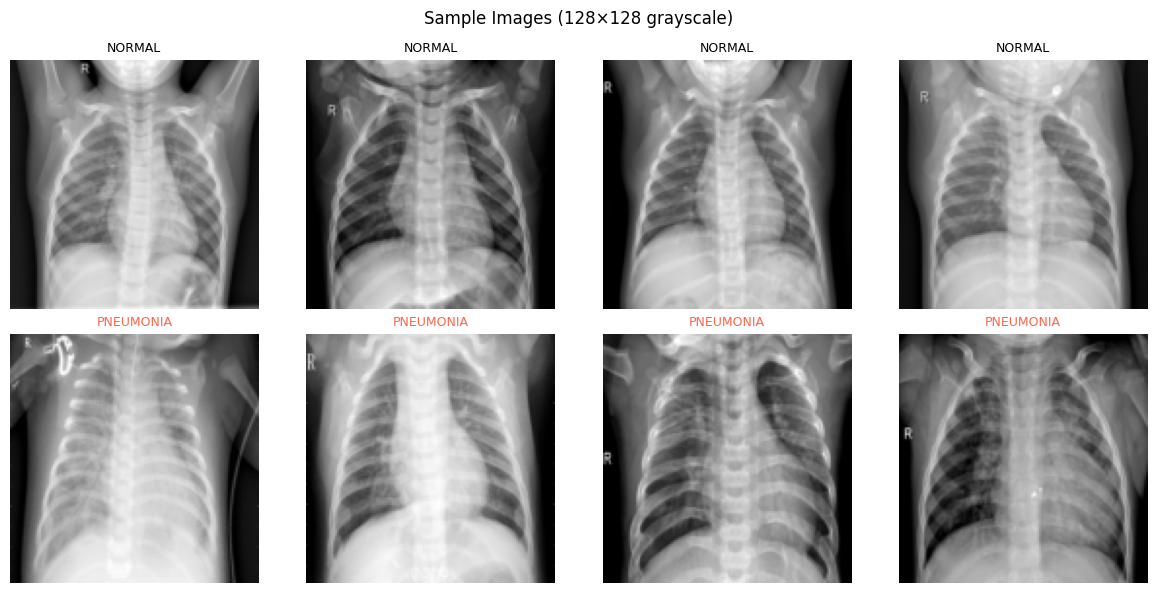


Standardising …
PCA → 150 components …
  Variance explained: 91.3%  |  shape: (5216, 150)


In [5]:
# ── 4. SAMPLE IMAGES ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, idx in zip(axes[0], np.where(y_train == -1)[0][:4]):
    ax.imshow(X_train[idx].reshape(IMG_SIZE, IMG_SIZE), cmap="gray")
    ax.set_title("NORMAL", fontsize=9); ax.axis("off")
for ax, idx in zip(axes[1], np.where(y_train ==  1)[0][:4]):
    ax.imshow(X_train[idx].reshape(IMG_SIZE, IMG_SIZE), cmap="gray")
    ax.set_title("PNEUMONIA", fontsize=9, color="tomato"); ax.axis("off")
plt.suptitle("Sample Images (128×128 grayscale)"); plt.tight_layout(); plt.show()

# ── 5. PREPROCESSING: StandardScaler + PCA ───────────────────────────────────
print("\nStandardising …")
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f"PCA → {N_COMPONENTS} components …")
pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_val_pca   = pca.transform(X_val_sc)
X_test_pca  = pca.transform(X_test_sc)

var_exp = np.cumsum(pca.explained_variance_ratio_)[-1] * 100
print(f"  Variance explained: {var_exp:.1f}%  |  shape: {X_train_pca.shape}")

In [6]:
# ── 6. SOFT-MARGIN SVM (NumPy + SGD) ─────────────────────────────────────────
#
#  Primal objective:
#      min  ½‖w‖² + C · (1/N) Σ max(0, 1 − yᵢ(wᵀxᵢ + b))
#
#  Subgradient for a mini-batch B:
#      ∂/∂w = w − (C/|B|) Σ_{i: margin<1} yᵢ xᵢ
#      ∂/∂b =   − (C/|B|) Σ_{i: margin<1} yᵢ
#
class SoftMarginSVM:
    def __init__(self, C=1.0, lr=0.01, n_epochs=50,
                 batch_size=64, lr_decay=0.95):
        self.C, self.lr0    = C, lr
        self.n_epochs       = n_epochs
        self.batch_size     = batch_size
        self.lr_decay       = lr_decay
        self.w = self.b     = None
        self.train_losses   = []
        self.val_losses     = []

    # ── loss ──────────────────────────────────────────────────────────────────
    def _loss(self, X, y):
        margin = y * (X @ self.w + self.b)
        hinge  = np.maximum(0.0, 1.0 - margin).mean()
        return 0.5 * self.w @ self.w + self.C * hinge

    # ── one SGD step ──────────────────────────────────────────────────────────
    def _step(self, X_b, y_b, lr):
        B      = len(y_b)
        margin = y_b * (X_b @ self.w + self.b)
        mask   = margin < 1                        # hinge active

        dw = self.w.copy()
        db = 0.0
        if mask.any():
            dw -= (self.C / B) * (y_b[mask, None] * X_b[mask]).sum(0)
            db  = -(self.C / B) * y_b[mask].sum()

        self.w -= lr * dw
        self.b -= lr * db

    # ── fit ───────────────────────────────────────────────────────────────────
    def fit(self, X, y, X_val=None, y_val=None, verbose=True):
        N, D   = X.shape
        self.w = np.zeros(D)
        self.b = 0.0
        lr     = self.lr0
        yf     = y.astype(np.float64)
        yvf    = y_val.astype(np.float64) if y_val is not None else None

        for ep in range(1, self.n_epochs + 1):
            perm = np.random.permutation(N)
            for s in range(0, N, self.batch_size):
                idx = perm[s:s + self.batch_size]
                self._step(X[idx], yf[idx], lr)

            lr *= self.lr_decay
            self.train_losses.append(self._loss(X, yf))
            if X_val is not None:
                self.val_losses.append(self._loss(X_val, yvf))

            if verbose and (ep % 10 == 0 or ep == 1):
                vs = f"  val={self.val_losses[-1]:.4f}" if X_val is not None else ""
                print(f"  epoch {ep:>3}/{self.n_epochs} "
                      f"train={self.train_losses[-1]:.4f}{vs}  lr={lr:.5f}")
        print("Training complete ✓")
        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        return np.sign(self.decision_function(X)).astype(np.int32)



Training Soft-Margin SVM …
  epoch   1/50 train=0.6435  val=0.4998  lr=0.00950
  epoch  10/50 train=0.6492  val=0.7959  lr=0.00599
  epoch  20/50 train=0.2704  val=1.0767  lr=0.00358
  epoch  30/50 train=0.1279  val=0.3771  lr=0.00215
  epoch  40/50 train=0.1420  val=0.4893  lr=0.00129
  epoch  50/50 train=0.1023  val=0.4401  lr=0.00077
Training complete ✓
Time: 0.3s


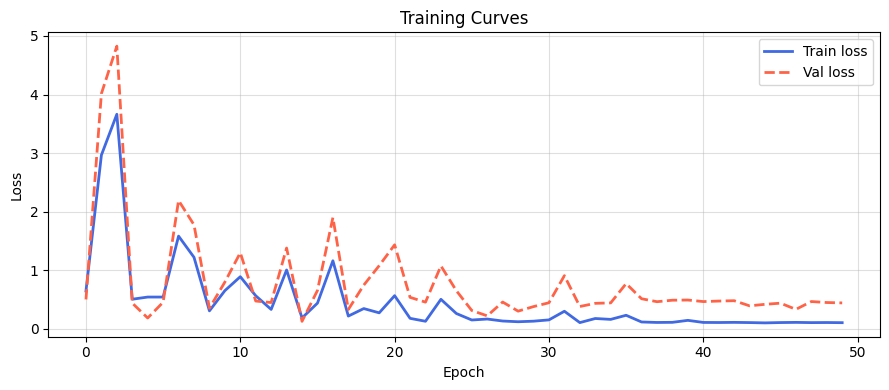

In [7]:


# ── 7. TRAIN ──────────────────────────────────────────────────────────────────
print("\nTraining Soft-Margin SVM …")
svm = SoftMarginSVM(C=C, lr=LR, n_epochs=N_EPOCHS,
                    batch_size=BATCH_SIZE, lr_decay=LR_DECAY)
t0 = time.time()
svm.fit(X_train_pca, y_train, X_val_pca, y_val)
print(f"Time: {time.time()-t0:.1f}s")

# Loss curves
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(svm.train_losses, label="Train loss",  lw=2, color="royalblue")
ax.plot(svm.val_losses,   label="Val loss",    lw=2, color="tomato", ls="--")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Training Curves"); ax.legend(); ax.grid(alpha=.4)
plt.tight_layout(); plt.show()

In [8]:


# ── 8. EVALUATION METRICS (pure NumPy) ───────────────────────────────────────
#
#  Positive class = PNEUMONIA (+1)
#
#  Precision = TP / (TP + FP)
#  Recall    = TP / (TP + FN)
#  F1        = 2 · P · R / (P + R)
#
def evaluate(y_true, y_pred, split=""):
    tp = int(((y_pred ==  1) & (y_true ==  1)).sum())
    fp = int(((y_pred ==  1) & (y_true == -1)).sum())
    fn = int(((y_pred == -1) & (y_true ==  1)).sum())
    tn = int(((y_pred == -1) & (y_true == -1)).sum())

    acc  = (tp + tn) / len(y_true)
    prec = tp / (tp + fp) if tp + fp > 0 else 0.0
    rec  = tp / (tp + fn) if tp + fn > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if prec + rec > 0 else 0.0

    print(f"\n{'═'*42}")
    print(f"  {split} set results")
    print(f"{'═'*42}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  Confusion Matrix (positive = PNEUMONIA)")
    print(f"              Pred POS   Pred NEG")
    print(f"  True POS :   {tp:5d}      {fn:5d}")
    print(f"  True NEG :   {fp:5d}      {tn:5d}")
    print(f"{'═'*42}")
    

    return dict(acc=acc, prec=prec, rec=rec, f1=f1,
                tp=tp, fp=fp, fn=fn, tn=tn)


y_test_pred  = svm.predict(X_test_pca)
y_train_pred = svm.predict(X_train_pca)
y_val_pred   = svm.predict(X_val_pca)

train_m = evaluate(y_train, y_train_pred, "Train")
val_m   = evaluate(y_val,   y_val_pred,   "Val")
test_m  = evaluate(y_test,  y_test_pred,  "Test")


══════════════════════════════════════════
  Train set results
══════════════════════════════════════════
  Accuracy  : 0.9691
  Precision : 0.9745
  Recall    : 0.9843
  F1-Score  : 0.9793
  Confusion Matrix (positive = PNEUMONIA)
              Pred POS   Pred NEG
  True POS :    3814         61
  True NEG :     100       1241
══════════════════════════════════════════

══════════════════════════════════════════
  Val set results
══════════════════════════════════════════
  Accuracy  : 0.7500
  Precision : 0.6667
  Recall    : 1.0000
  F1-Score  : 0.8000
  Confusion Matrix (positive = PNEUMONIA)
              Pred POS   Pred NEG
  True POS :       8          0
  True NEG :       4          4
══════════════════════════════════════════

══════════════════════════════════════════
  Test set results
══════════════════════════════════════════
  Accuracy  : 0.7548
  Precision : 0.7215
  Recall    : 0.9897
  F1-Score  : 0.8346
  Confusion Matrix (positive = PNEUMONIA)
              Pred POS

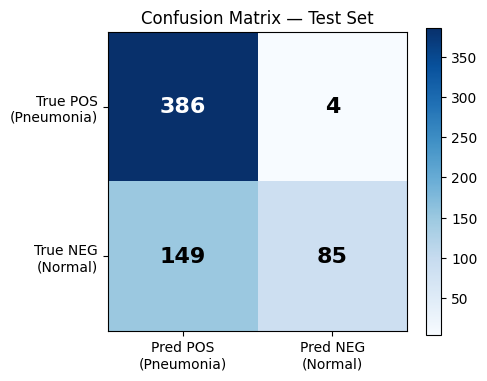

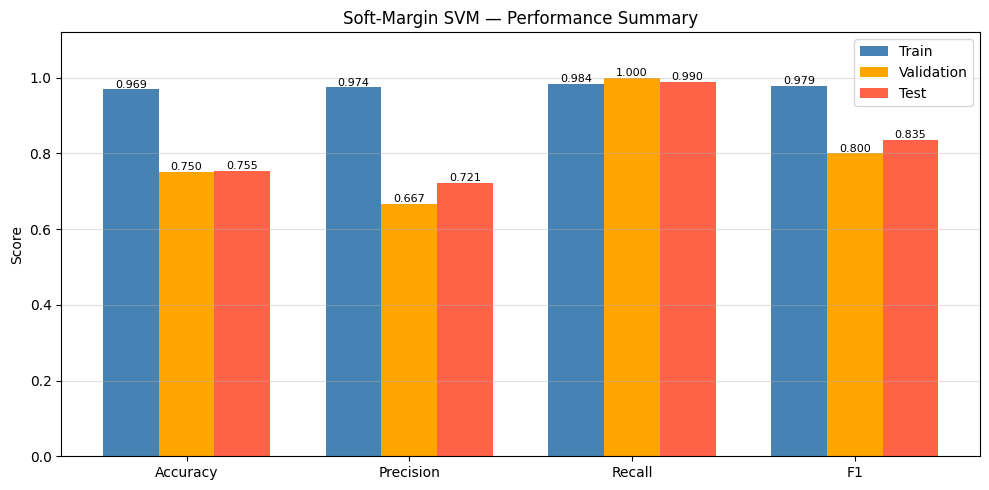

In [9]:


# ── 9. PLOTS ──────────────────────────────────────────────────────────────────

# 9-A  Confusion matrix (test)
cm = np.array([[test_m["tp"], test_m["fn"]],
               [test_m["fp"], test_m["tn"]]])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=16,
                fontweight="bold",
                color="white" if cm[i,j] > cm.max()*0.6 else "black")
ax.set_xticks([0,1]); ax.set_xticklabels(["Pred POS\n(Pneumonia)", "Pred NEG\n(Normal)"])
ax.set_yticks([0,1]); ax.set_yticklabels(["True POS\n(Pneumonia)", "True NEG\n(Normal)"])
ax.set_title("Confusion Matrix — Test Set"); plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

# 9-B  Metrics bar chart
metrics   = ["Accuracy", "Precision", "Recall", "F1"]
keys      = ["acc", "prec", "rec", "f1"]
train_v   = [train_m[k] for k in keys]
val_v     = [val_m[k]   for k in keys]
test_v    = [test_m[k]  for k in keys]

x = np.arange(len(metrics)); bw = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - bw, train_v, bw, label="Train",      color="steelblue")
b2 = ax.bar(x,      val_v,   bw, label="Validation", color="orange")
b3 = ax.bar(x + bw, test_v,  bw, label="Test",       color="tomato")
for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + .005,
                f"{bar.get_height():.3f}",
                ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.12); ax.set_ylabel("Score")
ax.set_title("Soft-Margin SVM — Performance Summary")
ax.legend(); ax.grid(axis="y", alpha=.4)
plt.tight_layout(); plt.show()

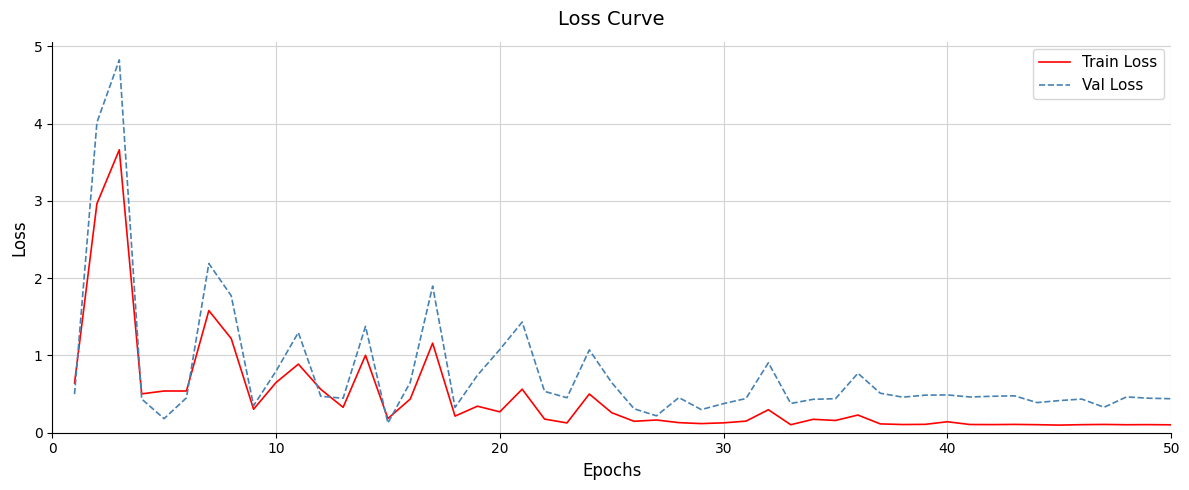

In [10]:
def plot_loss(train_losses, val_losses=None, title="Loss - PCA Features + Mini-batch SGD"):
    epochs = np.arange(1, len(train_losses) + 1)

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(epochs, train_losses,
            color="red", linewidth=1.2, label="Train Loss")

    if val_losses and len(val_losses) == len(train_losses):
        ax.plot(epochs, val_losses,
                color="steelblue", linewidth=1.2,
                linestyle="--", label="Val Loss")
        ax.legend(fontsize=11)

    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel("Epochs", fontsize=12)
    ax.set_ylabel("Loss",   fontsize=12)

    ax.set_xlim(0, len(train_losses))
    ax.set_ylim(bottom=0)

    ax.grid(True, color="lightgray", linewidth=0.8)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_loss(svm.train_losses, svm.val_losses,
          title="Loss Curve")